# Convolutional Autoencoder (CAE) cho ảnh vệ tinh Himawari-8

Notebook này xây dựng một **Convolutional Autoencoder** hoàn chỉnh bằng TensorFlow/Keras để học cách nén (encode) và tái tạo (decode) ảnh vệ tinh Himawari-8 (đã convert từ `.DAT` sang `.PNG`).

**Pipeline tổng quát:**

```
Ảnh gốc → Encoder → Latent Representation → Decoder → Ảnh tái tạo
```

Notebook được thiết kế để chạy tốt kể cả với dataset rất nhỏ (10–15 ảnh), phù hợp cho việc thử nghiệm ban đầu trước khi mở rộng dataset.

## Cell 1 — Import thư viện

Import toàn bộ thư viện cần dùng: TensorFlow/Keras để xây và train model, NumPy để xử lý mảng số, Matplotlib để vẽ ảnh/đồ thị, PIL để đọc ảnh PNG, scikit-learn để chia train/validation, scikit-image để tính PSNR.

In [2]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

# Cố định seed để kết quả có thể tái lập (reproducible)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Cell 2 — Kiểm tra TensorFlow và GPU

In ra phiên bản TensorFlow đang dùng và kiểm tra xem máy có GPU khả dụng hay không. Nếu không có GPU, model vẫn chạy được trên CPU — với dataset nhỏ (10–15 ảnh) thì CPU vẫn đủ nhanh.

In [3]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Tìm thấy {len(gpus)} GPU:")
    for gpu in gpus:
        print(" -", gpu)
else:
    print("Không tìm thấy GPU — sẽ chạy trên CPU (vẫn ổn với dataset nhỏ).")

TensorFlow version: 2.21.0
Keras version: 3.14.1
Không tìm thấy GPU — sẽ chạy trên CPU (vẫn ổn với dataset nhỏ).


## Cell 3 — Khai báo đường dẫn dataset

Khai báo đường dẫn đến thư mục `train` và `test` theo cấu trúc:

```
dataset/
├── train/
│   ├── image_001.png
│   └── ...
└── test/
    ├── image_001.png
    └── ...
```

Chỉnh lại `DATASET_DIR` cho đúng với vị trí thực tế trên máy bạn.

In [9]:

import os
import glob
from sklearn.model_selection import train_test_split

DATASET_DIR = r"C:\Users\quang\PycharmProjects\JupyterProject\output"

IMG_SIZE = 128   # resize ảnh về 128x128
CHANNELS = 1     # ảnh grayscale => 1 channel

# Tìm tất cả ảnh PNG trong output
all_paths = sorted(
    glob.glob(os.path.join(DATASET_DIR, "*.png"))
)

# Tự động chia 80% train - 20% test
train_paths, test_paths = train_test_split(
    all_paths,
    test_size=0.2,
    random_state=42
)

print(f"Tổng số ảnh tìm thấy: {len(all_paths)}")
print(f"Số ảnh train: {len(train_paths)}")
print(f"Số ảnh test:  {len(test_paths)}")

assert len(train_paths) > 0, (
    "Không tìm thấy ảnh .png nào trong thư mục output — "
    "kiểm tra lại DATASET_DIR."
)


Tổng số ảnh tìm thấy: 12
Số ảnh train: 9
Số ảnh test:  3


## Cell 4 — Load ảnh

Đọc toàn bộ ảnh PNG từ đĩa vào bộ nhớ dưới dạng đối tượng `PIL.Image`, giữ nguyên kích thước gốc ở bước này (chưa resize/normalize) — mục đích là để ở Cell 6 ta có thể so sánh ảnh **trước và sau** preprocessing.

In [10]:
def load_raw_images(paths):
    """Đọc danh sách ảnh PNG, trả về list các PIL.Image (giữ nguyên gốc)."""
    images = []
    for p in paths:
        img = Image.open(p)
        images.append(img)
    return images

raw_train_images = load_raw_images(train_paths)
raw_test_images = load_raw_images(test_paths) if test_paths else []

print(f"Đã load {len(raw_train_images)} ảnh train, {len(raw_test_images)} ảnh test.")
print("Kích thước ảnh đầu tiên (gốc):", raw_train_images[0].size, "| mode:", raw_train_images[0].mode)

Đã load 9 ảnh train, 3 ảnh test.
Kích thước ảnh đầu tiên (gốc): (1500, 1200) | mode: L


## Cell 5 — Preprocessing

Với mỗi ảnh:

1. Chuyển về **grayscale** (`convert("L")`) nếu ảnh đang ở dạng RGB/RGBA.
2. **Resize** về `128 × 128`.
3. Chuẩn hóa (**normalize**) giá trị pixel từ khoảng `[0, 255]` về `[0, 1]` bằng cách chia cho 255 — giúp model học ổn định hơn (gradient không bị quá lớn/quá nhỏ).
4. Thêm **channel dimension** để mảng có shape `(128, 128, 1)` thay vì `(128, 128)`, vì các layer Conv2D của Keras luôn kỳ vọng đầu vào có chiều channel.

Sau đó, vì dataset ban đầu rất nhỏ (10–15 ảnh), ta trích một phần nhỏ từ tập train làm **validation set**. Nếu số ảnh quá ít (dưới 5 ảnh) để chia tách có ý nghĩa, ta dùng luôn tập train làm validation và in cảnh báo — với dataset siêu nhỏ, validation set riêng biệt gần như không đáng tin cậy về mặt thống kê, chỉ mang tính tham khảo.

In [11]:
def preprocess_image(img: Image.Image, size=IMG_SIZE):
    """Grayscale -> resize -> normalize [0,1] -> shape (size, size, 1)"""
    if img.mode != "L":
        img = img.convert("L")
    img = img.resize((size, size), Image.LANCZOS)
    arr = np.array(img).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=-1)  # (H, W) -> (H, W, 1)
    return arr

def preprocess_dataset(pil_images):
    return np.stack([preprocess_image(img) for img in pil_images], axis=0)

X_train_full = preprocess_dataset(raw_train_images)
X_test = preprocess_dataset(raw_test_images) if raw_test_images else None

print("Shape X_train_full:", X_train_full.shape)
if X_test is not None:
    print("Shape X_test:      ", X_test.shape)

# Chia train/validation
n_train = len(X_train_full)
if n_train >= 5:
    X_train, X_val = train_test_split(X_train_full, test_size=max(1, int(0.2 * n_train)),
                                       random_state=SEED)
else:
    print("[Cảnh báo] Dataset quá nhỏ (<5 ảnh) để chia validation có ý nghĩa thống kê.")
    print("           Dùng toàn bộ tập train làm validation (chỉ mang tính tham khảo).")
    X_train, X_val = X_train_full, X_train_full

print(f"Số ảnh train: {len(X_train)} | Số ảnh validation: {len(X_val)}")

Shape X_train_full: (9, 128, 128, 1)
Shape X_test:       (3, 128, 128, 1)
Số ảnh train: 8 | Số ảnh validation: 1


## Cell 6 — Visualize ảnh trước và sau preprocessing

So sánh trực quan một vài ảnh gốc (chưa xử lý) với ảnh sau khi đã grayscale + resize + normalize, để kiểm tra pipeline preprocessing có hoạt động đúng không.

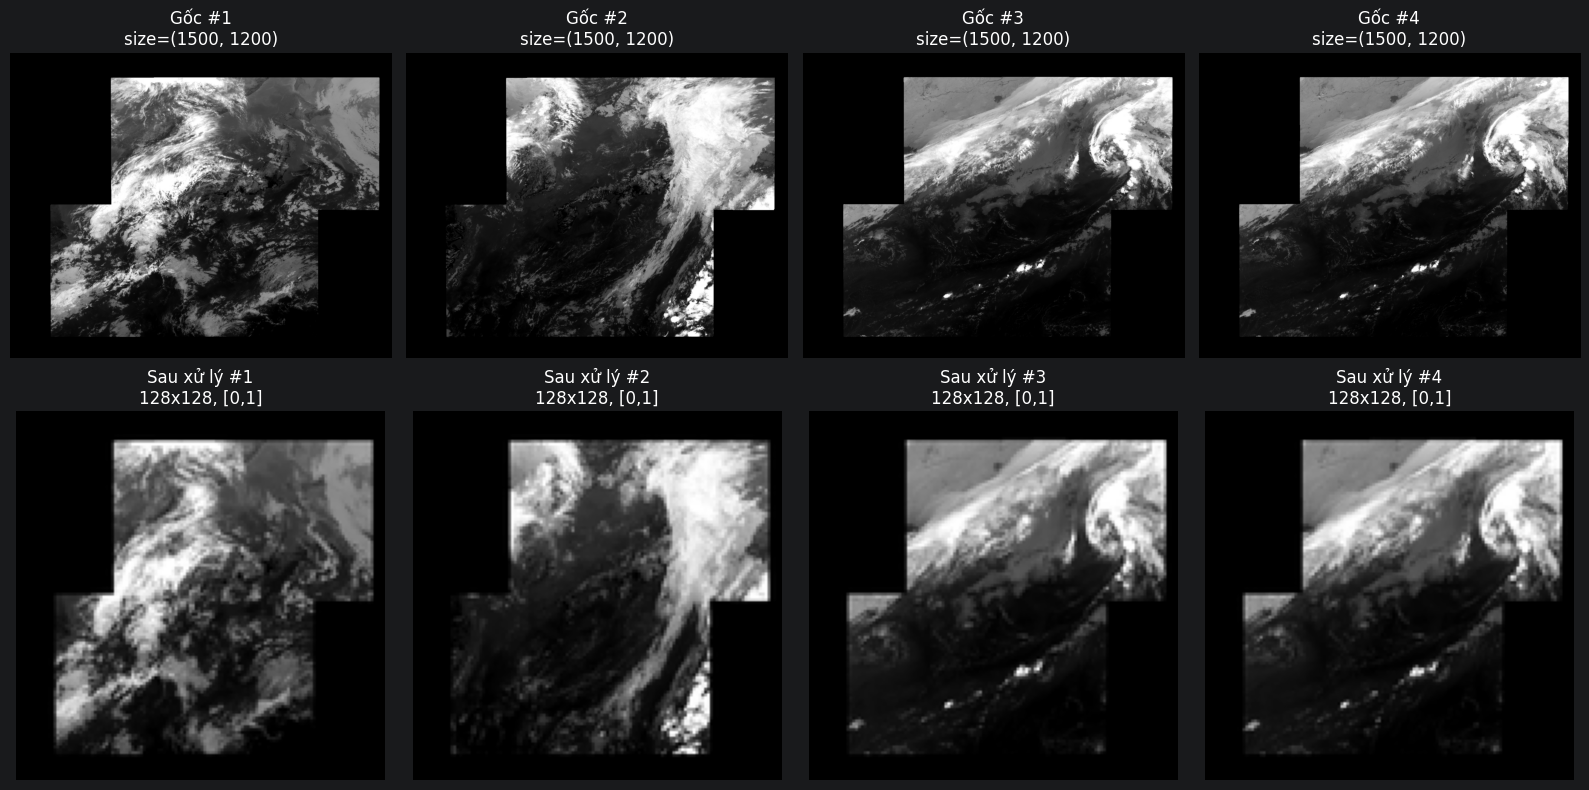

In [12]:
n_show = min(4, len(raw_train_images))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for i in range(n_show):
    # Ảnh gốc
    axes[0, i].imshow(raw_train_images[i], cmap="gray")
    axes[0, i].set_title(f"Gốc #{i+1}\nsize={raw_train_images[i].size}")
    axes[0, i].axis("off")

    # Ảnh sau preprocessing (bỏ channel dim để imshow)
    axes[1, i].imshow(X_train_full[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Sau xử lý #{i+1}\n{IMG_SIZE}x{IMG_SIZE}, [0,1]")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Cell 7 — Xây dựng Encoder

**Encoder** có nhiệm vụ nén ảnh đầu vào (128×128×1) thành một biểu diễn nhỏ gọn hơn nhiều — gọi là **latent representation** (16×16×128 trong kiến trúc này).

Giải thích từng thành phần:

- **`Conv2D`**: quét một bộ lọc (filter/kernel) nhỏ (3×3) trượt qua toàn bộ ảnh để phát hiện các đặc trưng (feature) như cạnh, góc, kết cấu (texture), vùng mây, vùng địa hình... Mỗi filter tạo ra một "feature map". Càng nhiều filter (channels) thì mạng càng học được nhiều loại đặc trưng khác nhau.
- **`MaxPooling2D`**: giảm kích thước không gian (width × height) của feature map xuống một nửa bằng cách chỉ giữ lại giá trị lớn nhất trong mỗi vùng 2×2. Việc này giúp mạng tóm lược thông tin quan trọng nhất, giảm số lượng tính toán, và làm cho các đặc trưng học được ít nhạy cảm hơn với các dịch chuyển nhỏ trong ảnh.
- **Tại sao kích thước ảnh giảm dần (128→64→32→16)**: mỗi lần pooling giữ lại thông tin "cô đọng" hơn — mạng dần chuyển từ nhìn từng pixel riêng lẻ sang nhìn các cấu trúc/pattern lớn hơn, mang tính ngữ nghĩa cao hơn.
- **Tại sao số lượng channels tăng dần (32→64→128)**: khi kích thước không gian giảm, mạng cần nhiều channel hơn để bù lại — mỗi channel đại diện cho một loại đặc trưng khác nhau, giúp mạng không bị mất thông tin quan trọng dù ảnh đã bị thu nhỏ.
- **Latent representation**: là "bản nén" của ảnh gốc — một khối tensor nhỏ hơn nhiều so với ảnh gốc (16×16×128 = 32.768 giá trị, so với ảnh gốc 128×128×1 = 16.384 giá trị pixel) nhưng chứa đựng thông tin cốt lõi để có thể tái tạo lại ảnh gần giống bản gốc. Đây chính là "ngôn ngữ nén" mà Decoder sẽ dùng để giải mã ngược lại.

In [13]:
def build_encoder(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    inputs = keras.Input(shape=input_shape, name="encoder_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="enc_conv1")(inputs)
    # shape: 128x128x32
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool1")(x)
    # shape: 64x64x32

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="enc_conv2")(x)
    # shape: 64x64x64
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool2")(x)
    # shape: 32x32x64

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="enc_conv3")(x)
    # shape: 32x32x128
    latent = layers.MaxPooling2D((2, 2), padding="same", name="latent")(x)
    # shape: 16x16x128  <-- Latent Representation

    encoder = keras.Model(inputs, latent, name="encoder")
    return encoder

encoder = build_encoder()
print("Encoder input shape: ", encoder.input_shape)
print("Encoder output shape (latent):", encoder.output_shape)

Encoder input shape:  (None, 128, 128, 1)
Encoder output shape (latent): (None, 16, 16, 128)


## Cell 8 — Xây dựng Decoder

**Decoder** làm ngược lại với Encoder: nhận latent representation (16×16×128) và dần dần khôi phục lại ảnh có kích thước gốc (128×128×1).

- **`Conv2DTranspose`** (còn gọi là "transposed convolution" hoặc dân gian hay gọi nhầm là "deconvolution"): về bản chất vẫn là một phép convolution, nhưng được cấu hình (với `strides=2`) để **tăng** kích thước không gian của feature map thay vì giảm — ngược lại hoàn toàn với `Conv2D` + `MaxPooling2D` ở Encoder.
- **Khác với `Conv2D` ở điểm nào**: `Conv2D` thường giữ nguyên hoặc thu nhỏ kích thước ảnh; `Conv2DTranspose` với stride > 1 sẽ "chèn" thêm không gian giữa các pixel rồi mới áp filter lên, kết quả là ảnh đầu ra lớn hơn ảnh đầu vào.
- **Vì sao Decoder có thể tăng kích thước ảnh**: nhờ cơ chế stride của `Conv2DTranspose`, mỗi bước decode nhân đôi chiều rộng và chiều cao (16→32→64→128), đối xứng ngược lại với quá trình pooling ở Encoder.
- **Vì sao layer cuối dùng `sigmoid`**: vì ảnh đầu vào đã được normalize về khoảng `[0, 1]` (Cell 5), và hàm `sigmoid` luôn cho ra giá trị trong khoảng `(0, 1)` — phù hợp để model dự đoán trực tiếp giá trị pixel đã chuẩn hóa, giúp việc so khớp với `loss="mse"` (so với ảnh gốc cũng trong `[0,1]`) có ý nghĩa và ổn định hơn.

In [14]:
def build_decoder(latent_shape):
    latent_inputs = keras.Input(shape=latent_shape, name="decoder_input")

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation="relu",
                                padding="same", name="dec_convT1")(latent_inputs)
    # shape: 32x32x128

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu",
                                padding="same", name="dec_convT2")(x)
    # shape: 64x64x64

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu",
                                padding="same", name="dec_convT3")(x)
    # shape: 128x128x32

    outputs = layers.Conv2D(CHANNELS, (3, 3), activation="sigmoid",
                             padding="same", name="dec_output")(x)
    # shape: 128x128x1  <-- Ảnh tái tạo

    decoder = keras.Model(latent_inputs, outputs, name="decoder")
    return decoder

# latent_shape lấy từ output của encoder, bỏ chiều batch (phần tử đầu tiên = None)
latent_shape = encoder.output_shape[1:]
decoder = build_decoder(latent_shape)
print("Decoder input shape (latent):", decoder.input_shape)
print("Decoder output shape:        ", decoder.output_shape)

Decoder input shape (latent): (None, 16, 16, 128)
Decoder output shape:         (None, 128, 128, 1)


## Cell 9 — Ghép Encoder + Decoder thành Autoencoder

Ghép hai model `encoder` và `decoder` lại thành một model `autoencoder` duy nhất, nhận ảnh đầu vào và trả về ảnh tái tạo (đi qua cả hai bước encode rồi decode). `encoder` và `decoder` vẫn tồn tại độc lập, có thể gọi riêng để lấy latent representation hoặc để decode một latent tuỳ ý.

In [15]:
autoencoder_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name="autoencoder_input")
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = keras.Model(autoencoder_input, decoded, name="autoencoder")
print("Autoencoder input shape: ", autoencoder.input_shape)
print("Autoencoder output shape:", autoencoder.output_shape)

Autoencoder input shape:  (None, 128, 128, 1)
Autoencoder output shape: (None, 128, 128, 1)


## Cell 10 — Xem kiến trúc chi tiết của từng model

In ra `summary()` của cả ba model để kiểm tra shape tensor qua từng layer và tổng số tham số (parameters) cần train.

In [16]:
print("=" * 60)
print("ENCODER")
print("=" * 60)
encoder.summary()

print()
print("=" * 60)
print("DECODER")
print("=" * 60)
decoder.summary()

print()
print("=" * 60)
print("AUTOENCODER (Encoder + Decoder)")
print("=" * 60)
autoencoder.summary()

ENCODER


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (MaxPooling2D)           │ (None, 16, 16, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 16, 16, 128)    │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 1)    │       240,129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 11 — Compile model

- **Optimizer**: `Adam` với `learning_rate=1e-3` — thuật toán tối ưu phổ biến, hội tụ nhanh và ổn định cho hầu hết bài toán deep learning.
- **Loss**: `"mse"` (Mean Squared Error) — đo sai khác trung bình bình phương giữa từng pixel của ảnh gốc và ảnh tái tạo. Phù hợp với bài toán reconstruction vì ta muốn ảnh tái tạo càng gần giá trị pixel gốc càng tốt.

In [17]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
)
print("Đã compile autoencoder với optimizer=Adam(lr=1e-3), loss=mse")

Đã compile autoencoder với optimizer=Adam(lr=1e-3), loss=mse


## Cell 12 — Training

Với dataset chỉ khoảng 10–15 ảnh:

- **`batch_size`** nên nhỏ (2–4) — batch lớn hơn số ảnh train sẽ không hợp lý.
- **`epochs`** đặt cao (ví dụ 200) nhưng dùng **`EarlyStopping`** để tự dừng khi `val_loss` không cải thiện nữa, tránh overfitting và tránh tốn thời gian train vô ích.
- **`ModelCheckpoint`** tự động lưu lại phiên bản model có `val_loss` thấp nhất trong quá trình train, phòng trường hợp epoch cuối cùng không phải là epoch tốt nhất.

Lưu ý quan trọng: vì `autoencoder` là mô hình **tự giám sát (self-supervised)** — input và target (nhãn) là **cùng một ảnh** — nên ta truyền `X_train` làm cả input lẫn target: `autoencoder.fit(X_train, X_train, ...)`.

In [18]:
checkpoint_path = "best_autoencoder.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0
    ),
]

BATCH_SIZE = min(4, len(X_train))  # không để batch_size lớn hơn số ảnh train
EPOCHS = 200

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - loss: 0.1644 - val_loss: 0.1419
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.1626 - val_loss: 0.1398
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1593 - val_loss: 0.1360
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.1528 - val_loss: 0.1331
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1451 - val_loss: 0.1362
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.1344 - val_loss: 0.1253
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.1172 - val_loss: 0.1056
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0941 - val_loss: 0.0843
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0688 - val_loss: 0.0686
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0528 - val_loss: 0.0560
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0435 - val_loss: 0.0495
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.03

## Cell 13 — Vẽ đồ thị Training Loss / Validation Loss

- **Loss giảm dần theo epoch** nghĩa là model đang học tốt hơn — sai số giữa ảnh gốc và ảnh tái tạo ngày càng nhỏ.
- **Nếu `training loss` tiếp tục giảm nhưng `validation loss` lại tăng**: đây là dấu hiệu kinh điển của **overfitting** — model đang "học thuộc lòng" chi tiết của từng ảnh train thay vì học các đặc trưng tổng quát, nên không còn tái tạo tốt trên ảnh nó chưa từng thấy.
- **Với dataset rất nhỏ (10–15 ảnh)**: cần đặc biệt cẩn trọng khi diễn giải đồ thị loss — validation set chỉ có vài ảnh nên đường `val_loss` có thể dao động mạnh (noisy) và không thực sự đại diện thống kê đáng tin cậy. Kết quả tốt nhất nên được xác nhận thêm bằng cách nhìn trực tiếp ảnh tái tạo (Cell 16), chứ không chỉ dựa vào con số loss.

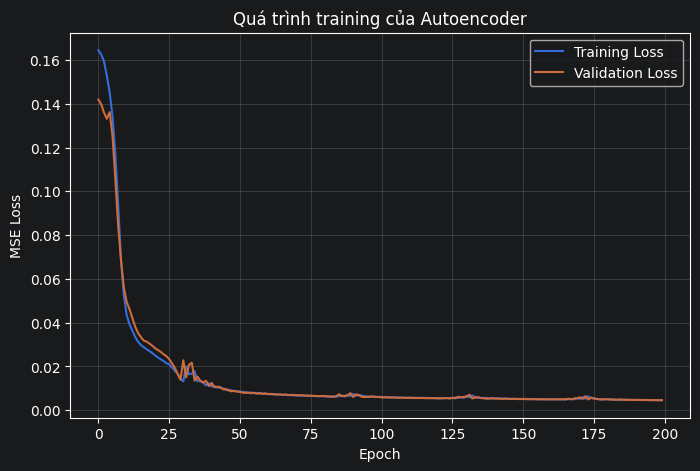

Loss cuối cùng   - train: 0.00458 | val: 0.00459
Loss thấp nhất   - train: 0.00458 | val: 0.00459


In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Quá trình training của Autoencoder")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Loss cuối cùng   - train: {history.history['loss'][-1]:.5f} | val: {history.history['val_loss'][-1]:.5f}")
print(f"Loss thấp nhất   - train: {min(history.history['loss']):.5f} | val: {min(history.history['val_loss']):.5f}")

## Cell 14 — Encode ảnh (test set)

Dùng `encoder` đã train để nén tập ảnh test thành latent representation.

In [20]:
eval_images = X_test if X_test is not None and len(X_test) > 0 else X_val
print(f"Dùng {'tập test' if (X_test is not None and len(X_test) > 0) else 'tập validation (do không có ảnh test)'} để đánh giá, gồm {len(eval_images)} ảnh.")

encoded_imgs = encoder.predict(eval_images, verbose=0)
print("Shape latent representation:", encoded_imgs.shape)

Dùng tập test để đánh giá, gồm 3 ảnh.
Shape latent representation: (3, 16, 16, 128)


## Cell 15 — Decode / tái tạo ảnh từ latent representation

Dùng `decoder` để giải mã ngược từ latent representation trở lại ảnh.

In [21]:
decoded_imgs = decoder.predict(encoded_imgs, verbose=0)
print("Shape ảnh tái tạo:", decoded_imgs.shape)

Shape ảnh tái tạo: (3, 128, 128, 1)


## Cell 16 — So sánh ảnh gốc vs ảnh tái tạo

Hiển thị ít nhất 5 cặp ảnh (Original / Reconstructed) để đánh giá trực quan chất lượng tái tạo.

Trước khi hiển thị, dùng `np.clip(decoded, 0, 1)` để đảm bảo giá trị pixel nằm chắc chắn trong khoảng hợp lệ `[0, 1]` — về lý thuyết `sigmoid` đã cho output trong `(0, 1)` nên thường không cần thiết, nhưng `clip` là bước an toàn giúp tránh lỗi hiển thị nếu có sai số số học (floating-point) rất nhỏ đẩy giá trị ra ngoài biên (ví dụ `1.0000001`).

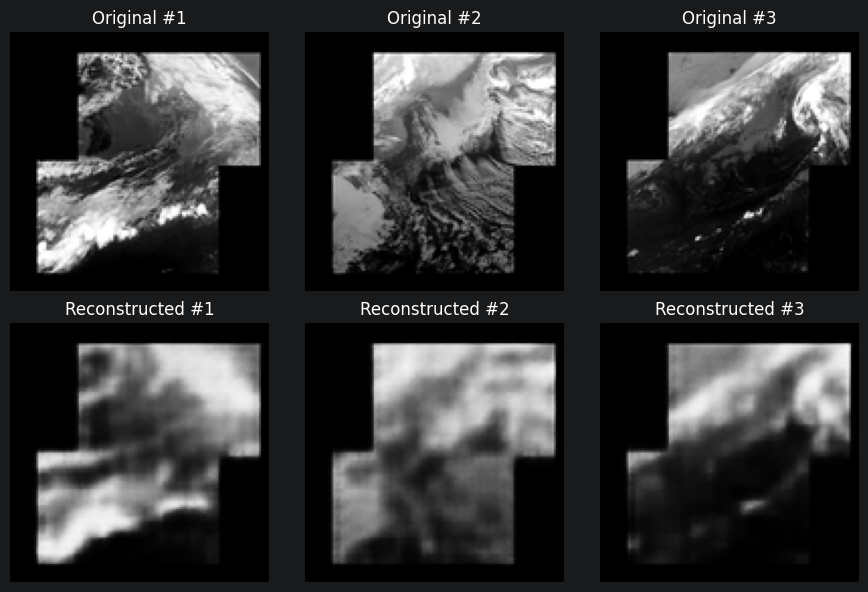

In [22]:
n_show = min(5, len(eval_images))

decoded_clipped = np.clip(decoded_imgs, 0, 1)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(eval_images[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Original #{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(decoded_clipped[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Reconstructed #{i+1}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Cell 17 — Đánh giá định lượng: MSE, MAE, PSNR

- **MSE (Mean Squared Error)**: trung bình bình phương sai khác pixel — cùng loại với loss đã dùng để train, càng nhỏ càng tốt.
- **MAE (Mean Absolute Error)**: trung bình trị tuyệt đối sai khác pixel — ít nhạy với outlier hơn MSE, dễ diễn giải hơn (đơn vị giống thang giá trị pixel).
- **PSNR (Peak Signal-to-Noise Ratio)**: đo tỉ lệ giữa tín hiệu gốc và nhiễu (sai số tái tạo), đơn vị dB — **càng cao càng tốt** (ảnh tái tạo càng gần ảnh gốc). Đây là metric phổ biến trong đánh giá chất lượng ảnh nén/tái tạo.

In [23]:
mse_val = np.mean((eval_images - decoded_clipped) ** 2)
mae_val = np.mean(np.abs(eval_images - decoded_clipped))

psnr_values = [
    psnr_metric(eval_images[i].squeeze(), decoded_clipped[i].squeeze(), data_range=1.0)
    for i in range(len(eval_images))
]
psnr_val = float(np.mean(psnr_values))

print(f"MSE trung bình:  {mse_val:.6f}")
print(f"MAE trung bình:  {mae_val:.6f}")
print(f"PSNR trung bình: {psnr_val:.2f} dB")

MSE trung bình:  0.004844
MAE trung bình:  0.039277
PSNR trung bình: 23.30 dB


## Cell 18 — Lưu model

Lưu riêng cả ba model (`encoder`, `decoder`, `autoencoder`) ra file `.keras` để có thể tái sử dụng sau này mà không cần train lại.

In [24]:
encoder.save("encoder.keras")
decoder.save("decoder.keras")
autoencoder.save("autoencoder.keras")

print("Đã lưu: encoder.keras, decoder.keras, autoencoder.keras")

Đã lưu: encoder.keras, decoder.keras, autoencoder.keras


## Cell 19 — Load lại model và kiểm tra

Load lại cả ba model từ file `.keras` và thử chạy lại trên 1 ảnh để xác nhận model load lên hoạt động đúng như model gốc.

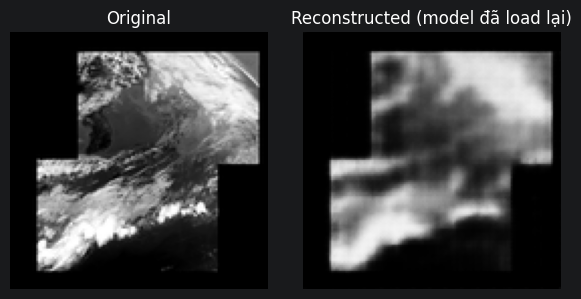

Model load lại hoạt động đúng như mong đợi.


In [25]:
loaded_encoder = keras.models.load_model("encoder.keras")
loaded_decoder = keras.models.load_model("decoder.keras")
loaded_autoencoder = keras.models.load_model("autoencoder.keras")

sample = eval_images[:1]
sample_reconstructed = loaded_autoencoder.predict(sample, verbose=0)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(sample_reconstructed, 0, 1).squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Reconstructed (model đã load lại)")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Model load lại hoạt động đúng như mong đợi." if sample_reconstructed is not None else "Có lỗi khi load model.")

In [ ]:
xem lai nguyen nhan sao bi mo, co phai la it du lieu khong
resize 512 giong anh goc
